# Tarea: Aplicaciones de Matplotlib en análisis de datos reales

En este notebook se desarrolla un análisis gráfico de un dataset real sobre salarios mensuales en México. Se generan diferentes tipos de visualizaciones y se guardan como imágenes PNG.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline

## Carga y exploración del dataset

Se utiliza un dataset de salarios mensuales en México con información de 10,000 personas.

In [2]:
df = pd.read_csv("salarios_mexico.csv")
print(f"Cantidad de registros: {len(df)}")
print(f"Columnas: {list(df.columns)}")
df.head(10)

Cantidad de registros: 10000
Columnas: ['id_persona', 'sexo', 'salario_mensual_mxn']


,id_persona,sexo,salario_mensual_mxn
0,1,Mujer,8835.21
1,2,Hombre,7577.81
2,3,Hombre,11114.60
3,4,Hombre,15053.63
4,5,Mujer,5546.31
5,6,Mujer,5546.38
6,7,Mujer,13706.46
7,8,Hombre,11653.46
8,9,Hombre,6087.37
9,10,Hombre,10641.52


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_persona           10000 non-null  int64  
 1   sexo                 10000 non-null  object 
 2   salario_mensual_mxn  10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB


In [4]:
df.describe()

,id_persona,salario_mensual_mxn
count,10000.00000,10000.000000
mean,5000.50000,7627.726749
std,2886.89568,4272.068114
min,1.00000,1000.000000
25%,2500.75000,4402.460000
50%,5000.50000,7466.810000
75%,7500.25000,10517.987500
max,10000.00000,24268.070000


In [5]:
print("Distribución por sexo:")
print(df["sexo"].value_counts())

Distribución por sexo:
sexo
Hombre    5461
Mujer     4539
Name: count, dtype: int64


## Gráfico 1: Histograma de distribución de salarios

El histograma muestra cómo se distribuyen los salarios en la muestra.

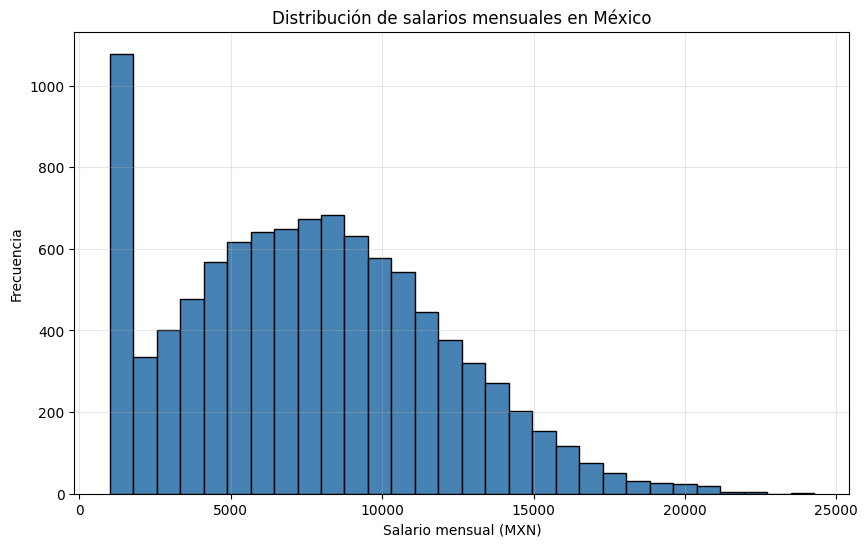

Imagen guardada como salarios_histograma.png


In [6]:
plt.figure(figsize=(10, 6))

plt.hist(df["salario_mensual_mxn"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribución de salarios mensuales en México")
plt.xlabel("Salario mensual (MXN)")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)

plt.savefig("salarios_histograma.png")
plt.show()

print("Imagen guardada como salarios_histograma.png")

**Observaciones:** La mayoría de los salarios se concentran en la parte central del rango. La distribución tiene forma de campana, lo que indica que hay pocos salarios muy bajos o muy altos, y la mayoría están cerca del promedio.

## Gráfico 2: Diagrama de dispersión entre índice y salario

Se grafica el ID de cada persona contra su salario para ver cómo están distribuidos los datos.

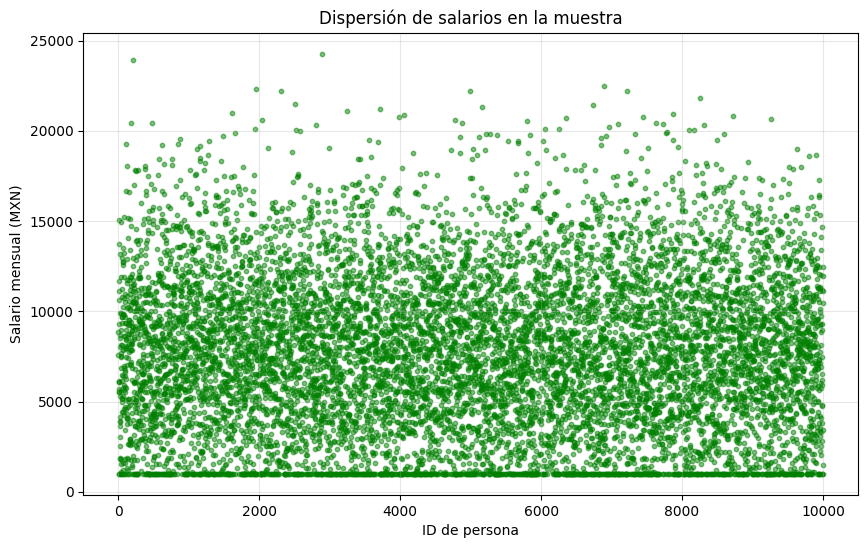

Imagen guardada como salarios_dispersion.png


In [7]:
plt.figure(figsize=(10, 6))

plt.scatter(df["id_persona"], df["salario_mensual_mxn"], alpha=0.5, color="green", s=10)
plt.title("Dispersión de salarios en la muestra")
plt.xlabel("ID de persona")
plt.ylabel("Salario mensual (MXN)")
plt.grid(True, alpha=0.3)

plt.savefig("salarios_dispersion.png")
plt.show()

print("Imagen guardada como salarios_dispersion.png")

**Observaciones:** Los salarios están repartidos de manera uniforme a lo largo de todos los IDs, lo que muestra que los datos no están ordenados por salario. Se ve una banda más densa en el centro donde hay más concentración de valores.

## Gráfico 3: Boxplot de salarios por sexo

El boxplot compara la distribución de salarios entre hombres y mujeres.

In [8]:
salarios_hombres = df[df["sexo"] == "Hombre"]["salario_mensual_mxn"]
salarios_mujeres = df[df["sexo"] == "Mujer"]["salario_mensual_mxn"]

print(f"Registros de hombres: {len(salarios_hombres)}")
print(f"Registros de mujeres: {len(salarios_mujeres)}")

Registros de hombres: 5461
Registros de mujeres: 4539


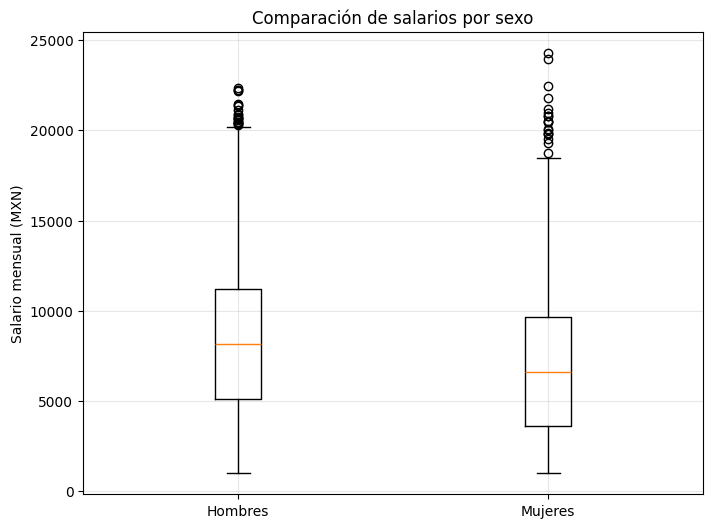

Imagen guardada como salarios_boxplot.png


In [12]:
plt.figure(figsize=(8, 6))

plt.boxplot([salarios_hombres, salarios_mujeres], tick_labels=["Hombres", "Mujeres"])
plt.title("Comparación de salarios por sexo")
plt.ylabel("Salario mensual (MXN)")
plt.grid(True, alpha=0.3)

plt.savefig("salarios_boxplot.png")
plt.show()

print("Imagen guardada como salarios_boxplot.png")

**Observaciones:** El boxplot permite ver la mediana (línea del centro), dónde está el 50% de los datos (la caja) y los valores que se salen de lo normal (los puntos fuera de los bigotes). Es útil para comparar rápidamente dos grupos.

## Análisis estadístico complementario

Se calculan las estadísticas por sexo para complementar los gráficos.

In [10]:
print("Estadísticas - Hombres:")
print(salarios_hombres.describe())
print("\nEstadísticas - Mujeres:")
print(salarios_mujeres.describe())

Estadísticas - Hombres:
count     5461.000000
mean      8283.844257
std       4315.711486
min       1000.000000
25%       5137.780000
50%       8174.980000
75%      11196.660000
max      22319.870000
Name: salario_mensual_mxn, dtype: float64

Estadísticas - Mujeres:
count     4539.000000
mean      6838.333113
std       4081.949294
min       1000.000000
25%       3634.355000
50%       6605.420000
75%       9648.455000
max      24268.070000
Name: salario_mensual_mxn, dtype: float64


In [11]:
print(f"Salario promedio hombres: ${salarios_hombres.mean():,.2f} MXN")
print(f"Salario promedio mujeres: ${salarios_mujeres.mean():,.2f} MXN")
print(f"Diferencia: ${salarios_hombres.mean() - salarios_mujeres.mean():,.2f} MXN")

Salario promedio hombres: $8,283.84 MXN
Salario promedio mujeres: $6,838.33 MXN
Diferencia: $1,445.51 MXN


## Conclusiones

Se aplicaron los conceptos de la sesión 39 para analizar un dataset real:

- El **histograma** mostró que los salarios tienen una distribución con forma de campana.
- El **diagrama de dispersión** permitió ver la variabilidad de los datos.
- El **boxplot** facilitó la comparación entre grupos.

Los tres gráficos fueron guardados como imágenes PNG usando `savefig()`, lo cual es útil para incluirlos en reportes o presentaciones.